# Multivariate HMM Regime Segmentation
Here we notebook implements a Multivariate Hidden Markov Model (HMM) approach to market regime segmentation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load data
data_path = r'../../../data/master_data.csv'
df = pd.read_csv(data_path)


df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (8066, 27)


,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,quarter,GDP_YoY,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,1994-01-27,477.049988,10.30,344500,10939.116,66.902,6.6,3474.9,0.008136,0.004358,...,1,0.034307,1,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN
1,1994-01-28,478.700012,9.94,356500,10939.116,66.902,6.6,3474.9,0.003459,0.008384,...,1,0.034307,1,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN
2,1994-01-31,481.609985,10.63,313800,10939.116,66.902,6.6,3474.9,0.006079,0.020425,...,1,0.034307,1,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN
3,1994-02-01,479.619995,10.65,303600,10939.116,67.047,6.6,3475.7,-0.004132,0.018474,...,1,0.034307,2,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN
4,1994-02-02,482.000000,10.61,307600,10939.116,67.047,6.6,3475.7,0.004962,0.018597,...,1,0.034307,2,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN


In [ ]:
# Prepare data for the Multivariate HMM
#features = [ret_col, 'VIX', 'RSI_14', 'MACD_Hist']
features = [ret_col, 'VIX']
df_clean = df.dropna(subset=features).copy().reset_index(drop=True)
X_raw = df_clean[features].values

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Features used: {features}")
print(f"Observation matrix shape: {X.shape}")
print(f"Scaled means: {X.mean(axis=0).round(4)}")
print(f"Scaled stds: {X.std(axis=0).round(4)}")

Features used: ['Return', 'VIX']
Observation matrix shape: (8066, 2)
Scaled means: [-0. -0.]
Scaled stds: [1. 1.]


In [ ]:
print("Fitting Multivariate Gaussian HMM (2 regimes)...")

# We use a Gaussian HMM with 2 components (Bull and Bear)
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)
hidden_states = model.predict(X)
smoothed_probs = model.predict_proba(X)

print(f"Model converged: {model.monitor_.converged}")

Fitting Multivariate Gaussian HMM (2 regimes)...
Model converged: True


In [ ]:
# Map states to Bull/Bear Regimes
means_scaled = model.means_
means_original = scaler.inverse_transform(means_scaled)

print("State 0 (Original Scale):")
print(f"  Mean Return: {means_original[0][0]:.6f}, Mean VIX: {means_original[0][1]:.6f}")
print("State 1 (Original Scale):")
print(f"  Mean Return: {means_original[1][0]:.6f}, Mean VIX: {means_original[1][1]:.6f}")

# define the Bull state as the one with the higher mean return
if means_original[0][0] > means_original[1][0]:
    bull_state = 0
    bear_state = 1
else:
    bull_state = 1
    bear_state = 0

print(f"\nAssigned State {bull_state} to Bull Regime")
print(f"Assigned State {bear_state} to Bear Regime")

# assign regime based on the highest probability
df_clean['prob_bull'] = smoothed_probs[:, bull_state]
df_clean['prob_bear'] = smoothed_probs[:, bear_state]
df_clean['regime'] = np.where(df_clean['prob_bull'] > 0.5, 'bull', 'bear')

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_clean[['Date', 'regime', 'prob_bull', 'prob_bear']], on='Date', how='left')
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nMultivariate HMM regime mapping complete.")
print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))

State 0 (Original Scale):
  Mean Return: 0.000750, Mean VIX: 14.513279
State 1 (Original Scale):
  Mean Return: -0.000016, Mean VIX: 25.917466

Assigned State 0 to Bull Regime
Assigned State 1 to Bear Regime

Multivariate HMM regime mapping complete.

Regime Counts:
regime
bull    4393
bear    3673
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.545
bear    0.455
Name: proportion, dtype: float64


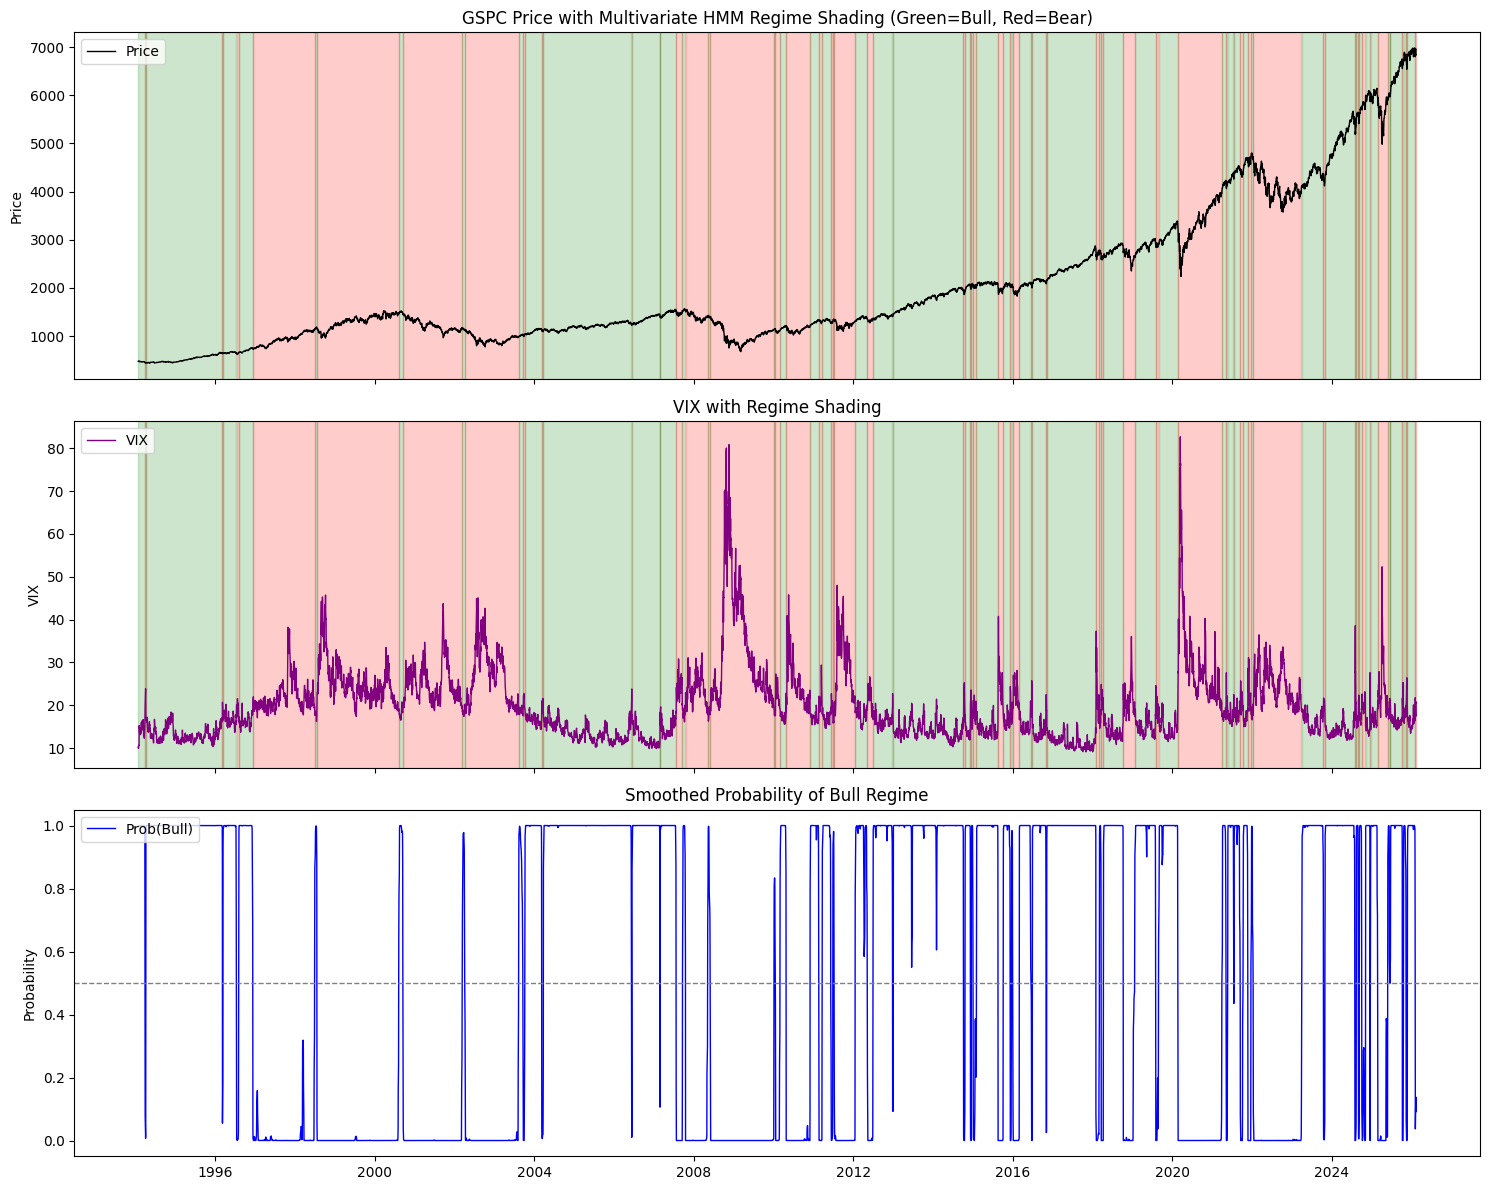

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Multivariate HMM Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')


df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 2: VIX with regime shading
ax2.plot(df['Date'], df['VIX'], color='purple', linewidth=1, label='VIX')
ax2.set_title('VIX with Regime Shading')
ax2.set_ylabel('VIX')
ax2.legend(loc='upper left')

for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax2.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 3: Smoothed Probability of Bull Regime
ax3.plot(df['Date'], df['prob_bull'], color='blue', linewidth=1, label='Prob(Bull)')
ax3.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax3.set_title('Smoothed Probability of Bull Regime')
ax3.set_ylabel('Probability')
ax3.set_ylim(-0.05, 1.05)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [ ]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'../../../data/multivariate_hmm_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")